# Week 1 Challenge Project
### Group 8: Kaitlyn Nguyen, Gianna Park, Emma Yang, Vrajesh Parikh
---
Hypothyroidism, also called underactive thyroid or low thyroid, is a disorder of the endocrine system in which the thyroid gland does not produce enough thyroid hormone. It can cause a number of symptoms, such as poor ability to tolerate cold, a feeling of tiredness, constipation, depression, and weight gain. Occasionally there may be swelling of the front part of the neck due to goitre. Untreated hypothyroidism during pregnancy can lead to delays in growth and intellectual development in the baby or cretinism.

Worldwide, too little iodine in the diet is the most common cause of hypothyroidism. In countries with enough iodine in the diet, the most common cause of hypothyroidism is the autoimmune condition Hashimoto's thyroiditis. Less common causes include: previous treatment with radioactive iodine, injury to the hypothalamus or the anterior pituitary gland, certain medications, a lack of a functioning thyroid at birth, or previous thyroid surgery. The diagnosis of hypothyroidism, when suspected, can be confirmed with blood tests measuring thyroid-stimulating hormone (TSH) and thyroxine levels.

Worldwide about one billion people are estimated to be iodine deficient; however, it is unknown how often this results in hypothyroidism. In the United States, hypothyroidism occurs in 0.3–0.4% of people.

And that is why we iodize salt.

![alt text](https://www.mayoclinic.org/-/media/kcms/gbs/patient-consumer/images/2013/11/15/17/39/ds00181_-ds00344_-ds00353_-ds00491_-ds00492_-ds00567_-ds00660_-my00709_im01872_thyroid_gif.jpg)



Background: Doctors all around the world need our help to predict whether a patient has hypothyroid disease. We have already overspent our budget to collect such complete data on about 30 attributes for 2800 patients--a good starting number, but a larger sample would certainly be preferred. Moving forward, however, we simply cannot afford to spend so much money on data collection. Therefore, we also need to determine which attributes are the most meaningful to the predictive models, and cut out the rest that don't contribute much.

The boss wants to see a **balanced** model that can predict with a **high sensitivity** and **high specificity** while using a ***low amount of features***. Collecting complete data such as this is very rare, very time-consuming, and often very expensive. By minimizing the number of features, it will optimize future data collection by deciding what needs to be collected, and what doesn't.



```
# This is formatted as code
```

# Loading the data

Let's read the data into a Pandas dataframe and look at the first 20 records.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

train_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.train.csv"
test_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.test.csv"

'''
names = [
    'Age','Sex','On Thyroxine','Query on Thyroxine','On Antithyroid Medication',
    'Sick','Pregnant','Thyroid Surgery','I131 Treatment','Query Hypothyroid',
    'Query Hyperthyroid','Lithium','Goiter','Tumor','Hypopituitary','Psych',
    'TSH Measured','TSH','T3 Measured','T3','TT4 Measured','TT4',
    'T4U Measured','T4U','FTI Measured','FTI','TBG Measured','TBG',
    'Referral Source','Class'
]
'''

train_data = pd.read_csv(train_url, header=0, na_values="?")
test_data = pd.read_csv(test_url, header=0)

train_data.columns = train_data.columns.str.strip().str.lower()
test_data.columns = test_data.columns.str.strip().str.lower()

# identify columns by what time of data they hold
numeric_columns = ["age", "tsh", "t3", "tt4", "t4u", "fti"]

# categorical columns are everything else (minus 'class')
categorical_columns = list(set(train_data.columns)-set(numeric_columns)-set(['class']))

# Preprocessing


1.   Clean class labels
2.   Drop referral source, tbg
3.   Convert sex data into binary
4.   Convert feature col to numeric

In [2]:
# preprocessing

def format_class_labels(df):
    df = df.copy()

    df["class"] = (
        df["class"]
        .astype(str)
        .str.replace(r"\.\|\d+", "", regex=True)
        .str.strip()
        .str.lower()
    )

    df["class"] = df["class"].replace({
        "negative": 0,
        "compensated hypothyroid": 1,
        "primary hypothyroid": 1,
        "secondary hypothyroid": 1
    })

    df = df.dropna(subset=["class"])
    df["class"] = df["class"].astype(int)

    return df

train_data = format_class_labels(train_data)
train_data.head()

/tmp/ipykernel_25871/2898347231.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace({


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,i131 treatment,query hypothyroid,...,tt4 measured,tt4,t4u measured,t4u,fti measured,fti,tbg measured,tbg,referral source,class
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,0
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.0,f,NaN,f,NaN,f,NaN,other,0
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,NaN,other,0
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.0,f,NaN,f,NaN,f,NaN,other,0
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,NaN,SVI,0


In [3]:
train_data = train_data.drop("referral source", axis=1)
test_data = test_data.drop("referral source", axis=1)

In [4]:
mapping = {
    **dict.fromkeys(["F", "f"], 0),
    **dict.fromkeys(["M", "t"], 1),
    "negative": 0,
    **dict.fromkeys([
        "compensated hypothyroid",
        "primary hypothyroid",
        "secondary hypothyroid"
    ], 1)
}

train_data.replace(mapping, inplace=True)
test_data.replace(mapping, inplace=True)

/tmp/ipykernel_25871/1794851132.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data.replace(mapping, inplace=True)
/tmp/ipykernel_25871/1794851132.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.replace(mapping, inplace=True)


In [5]:
train_data.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,i131 treatment,query hypothyroid,...,t3,tt4 measured,tt4,t4u measured,t4u,fti measured,fti,tbg measured,tbg,class
count,2799.00000,2690.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,...,2215.000000,2800.000000,2616.000000,2800.000000,2503.000000,2800.000000,2505.000000,2800.0,0.0,2800.000000
mean,51.84423,0.319703,0.117857,0.014286,0.012143,0.039286,0.014643,0.013929,0.017143,0.058214,...,2.024966,0.934286,109.072401,0.893929,0.997912,0.894643,110.787984,0.0,NaN,0.078571
std,20.46116,0.466448,0.322496,0.118687,0.109543,0.194309,0.120140,0.117215,0.129827,0.234190,...,0.824600,0.247826,35.392443,0.307984,0.194390,0.307068,32.883986,0.0,NaN,0.269117
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,2.000000,0.000000,0.310000,0.000000,2.000000,0.0,NaN,0.000000
25%,36.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.600000,1.000000,88.000000,1.000000,0.880000,1.000000,93.000000,0.0,NaN,0.000000
50%,54.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,1.000000,104.000000,1.000000,0.980000,1.000000,107.000000,0.0,NaN,0.000000
75%,67.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.400000,1.000000,125.000000,1.000000,1.080000,1.000000,124.000000,0.0,NaN,0.000000
max,455.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,10.600000,1.000000,430.000000,1.000000,2.120000,1.000000,395.000000,0.0,NaN,1.000000


In [6]:
train_data = train_data.drop_duplicates()

# Select X and Y and split data

In [7]:
# features for prediction
X_cols = [
    'age', 'sex', 'on thyroxine', 'query on thyroxine',
    'on antithyroid medication', 'sick', 'pregnant',
    'thyroid surgery', 'i131 treatment', 'query hypothyroid',
    'query hyperthyroid', 'lithium', 'goiter', 'tumor',
    'hypopituitary', 'psych', 'tsh measured', 'tsh',
    't3 measured', 't3', 'tt4 measured', 'tt4',
    't4u measured', 't4u', 'fti measured', 'fti',
    'tbg measured', 'tbg',
]

# output
y_col = 'class'

# 80% train, 20% split
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    train_data[X_cols],
    train_data[y_col],
    test_size=test_size,
    random_state=24
)

# Further split X and y of training into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=test_size,
    random_state=24
)

# Fill in missing values

In [8]:
missing_quantitative = X_train.columns[
    (X_train.isna().sum() > 0) &
    (X_train.dtypes != "object")
]

print(missing_quantitative)

Index(['age', 'sex', 'tsh', 't3', 'tt4', 't4u', 'fti', 'tbg'], dtype='object')


In [9]:
from sklearn.impute import SimpleImputer

missing_quantitative = ['age', 'tsh', 't3', 'tt4', 't4u', 'fti']

imputer_mean = SimpleImputer(
    missing_values=np.nan,
    strategy="mean"
)

# Learn means from training data only
imputer_mean.fit(X_train[missing_quantitative])

# Replace missing values
X_train[missing_quantitative] = imputer_mean.transform(
    X_train[missing_quantitative]
)

X_val[missing_quantitative] = imputer_mean.transform(
    X_val[missing_quantitative]
)

X_test[missing_quantitative] = imputer_mean.transform(
    X_test[missing_quantitative]
)

In [10]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nRemaining missing values in X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

X_train shape: (1761, 28)
X_val shape: (441, 28)
X_test shape: (551, 28)

Remaining missing values in X_train:
sex      64
tbg    1761
dtype: int64


# Data analysis and visualization

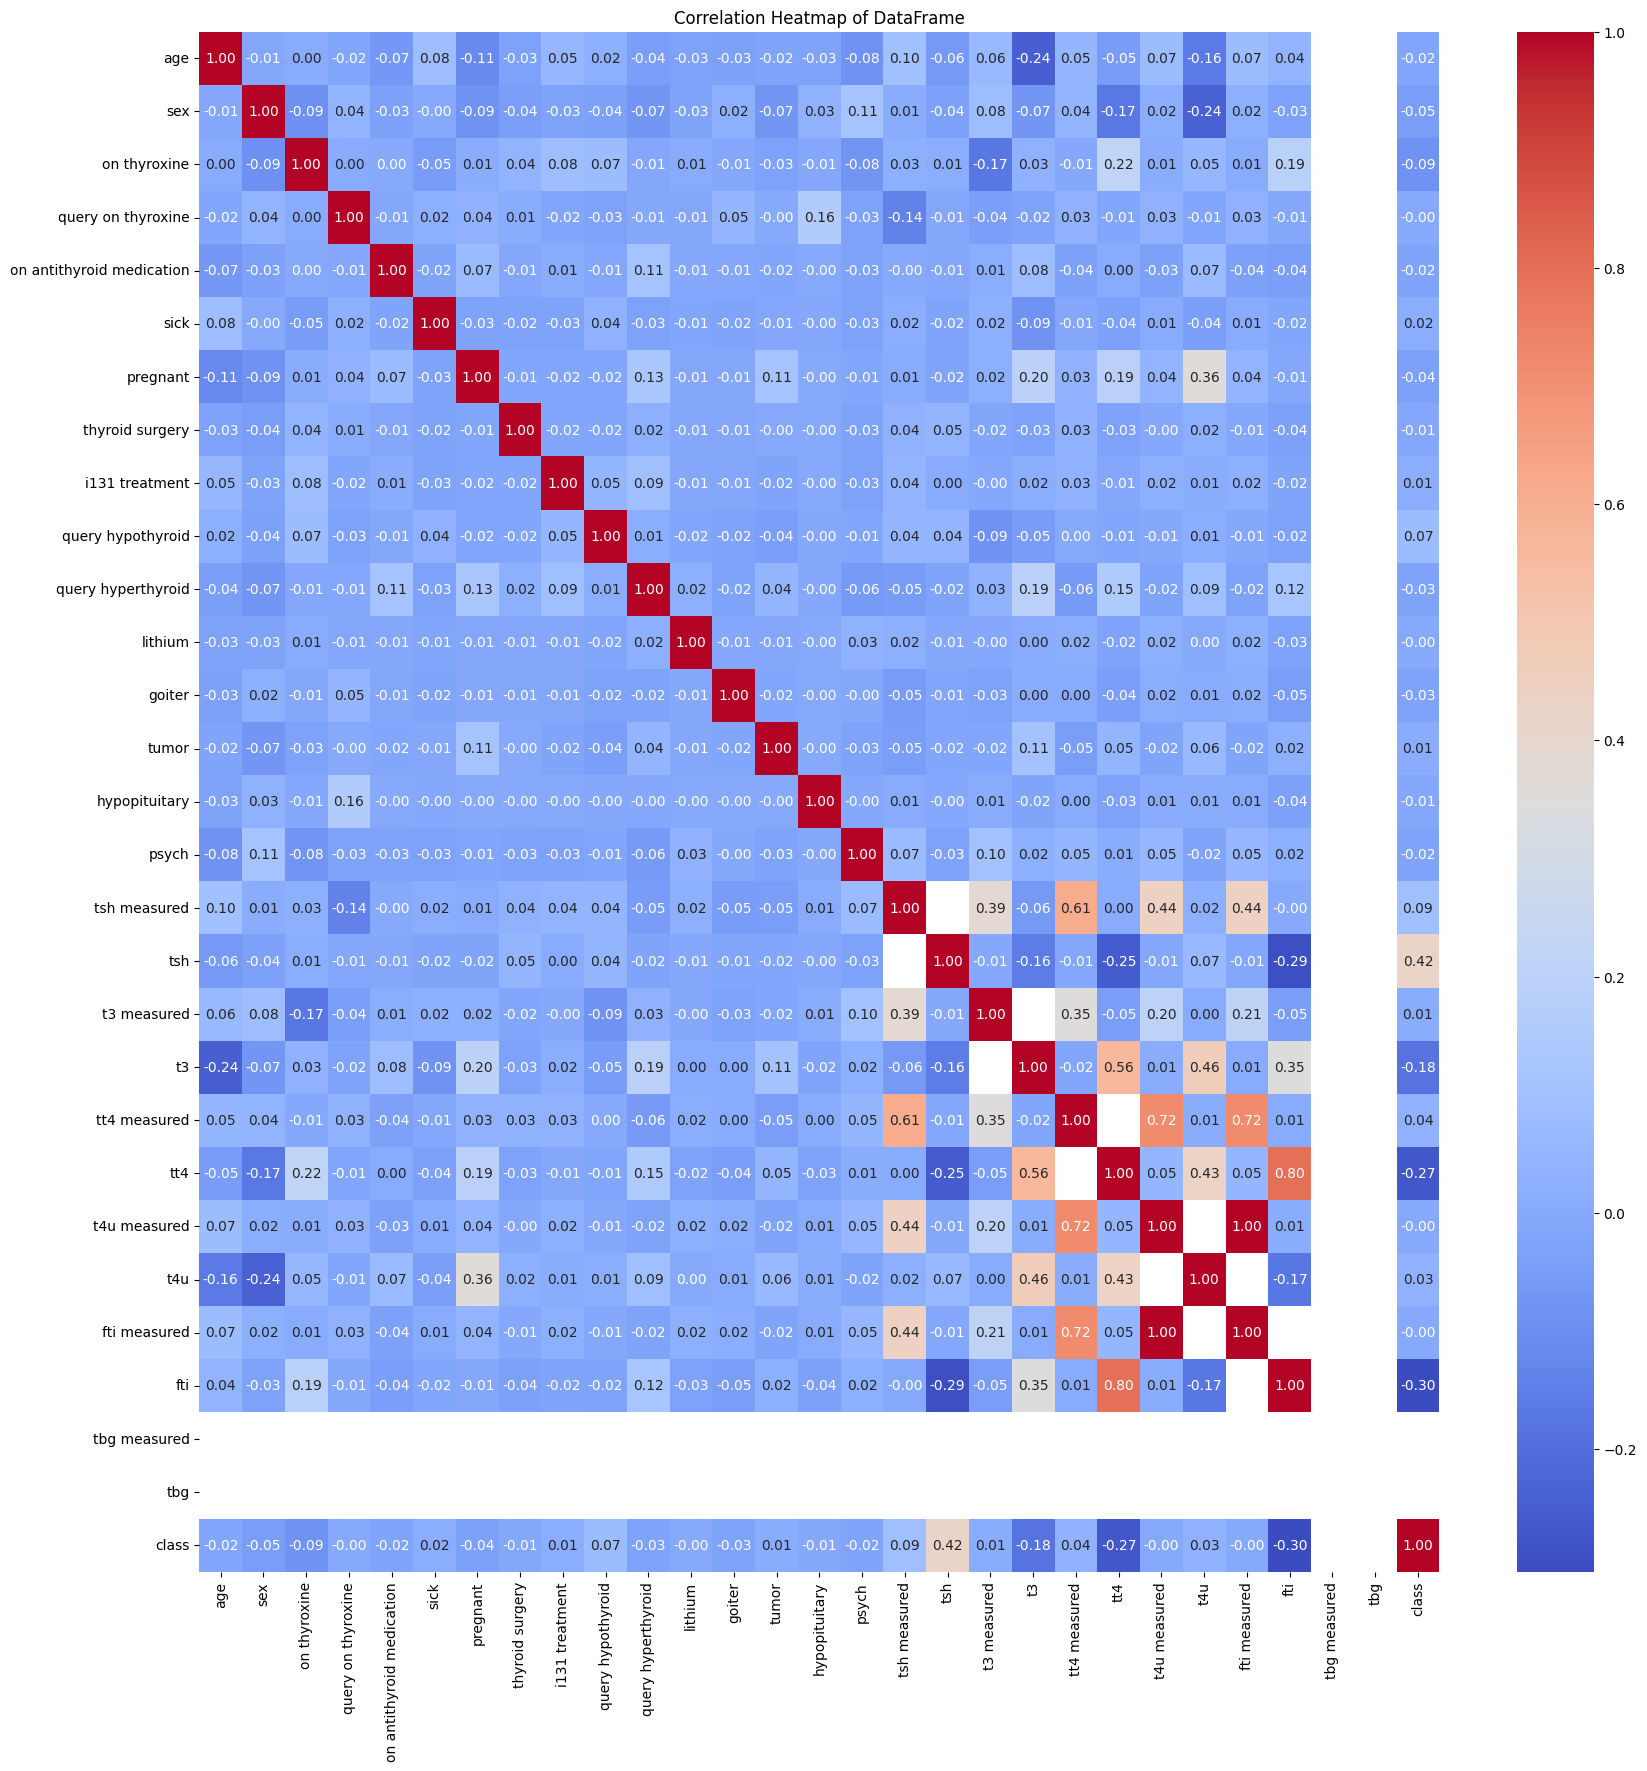

In [11]:
correlation_matrix = train_data.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of DataFrame')
plt.show()

# SVM Model (Gianna)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score

numeric_features = X_train.select_dtypes(
    include=np.number
).columns

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

svm_model = Pipeline([
    ("preprocessing", preprocessor),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=0
    ))
])

svm_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'i131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goit...
       't3 measured', 't3', 'tt4 measured', 'tt4', 't4u measured', 't4u',
       'fti measured', 'fti', 'tbg measured', 'tbg'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('svm',
                 SVC(class_weight='balanced', probability=True,
                     random_state=0))])

## SVM model evaluation, ROC, CM, importance

In [13]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Predictions
y_val_pred = svm_model.predict(X_val)
y_val_prob = svm_model.predict_proba(X_val)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


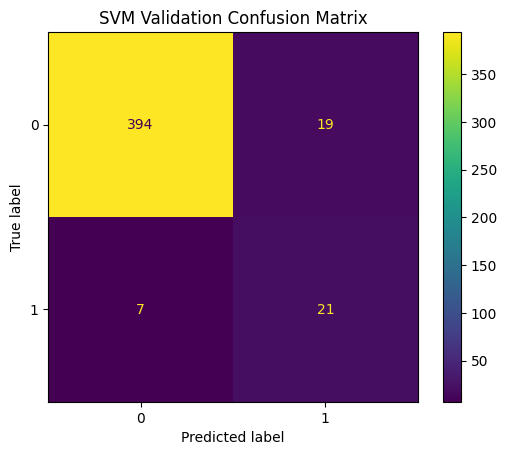

In [14]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot()
plt.title("SVM Validation Confusion Matrix")
plt.show()

In [15]:
y_val_probability = svm_model.predict_proba(X_val)[:, 1]

positive_class = svm_model.classes_[1]

y_val_binary = (y_val == positive_class).astype(int)

fpr, tpr, thresholds = roc_curve(
    y_val_binary,
    y_val_probability
)

roc_auc = roc_auc_score(
    y_val_binary,
    y_val_probability
)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9504496713939813


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


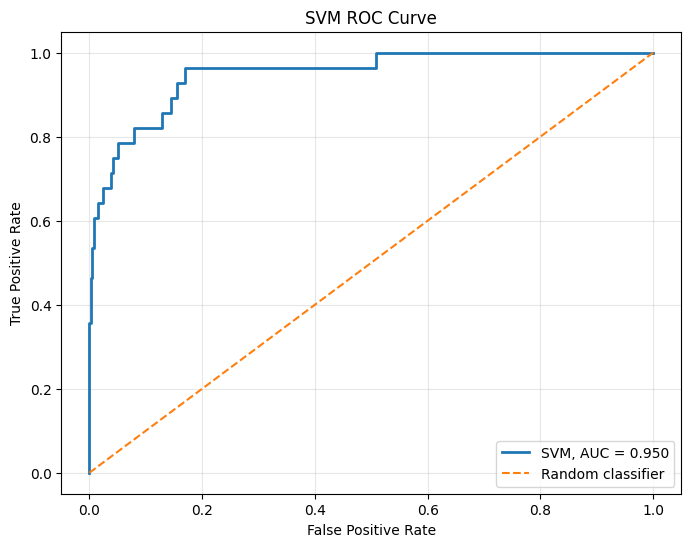

In [16]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM, AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [17]:
from sklearn.metrics import accuracy_score

# Make predictions
y_train_pred = svm_model.predict(X_train)
y_val_pred = svm_model.predict(X_val)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Training Accuracy:", train_accuracy * 100)
print("Validation Accuracy:", val_accuracy * 100)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Training Accuracy: 97.89892106757524
Validation Accuracy: 94.10430839002267


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [18]:
from sklearn.inspection import permutation_importance

# calculate feature importance on VAL data
result = permutation_importance(
    svm_model, # the model
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=0
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base

               Feature  Importance
17                 tsh    0.168039
16        tsh measured    0.023374
2         on thyroxine    0.021247
19                  t3    0.014165
7      thyroid surgery    0.010109
12              goiter    0.006624
6             pregnant    0.004142
21                 tt4    0.002620
13               tumor    0.002603
10  query hyperthyroid    0.002361


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base

# Random Forest (Kaitlyn)

In [19]:
random_forest = RandomForestClassifier(n_estimators=100, criterion = "entropy", random_state = 42,
                              max_depth=5, min_samples_leaf=5)

## Random Forest model evaluation, ROC, CM, importance

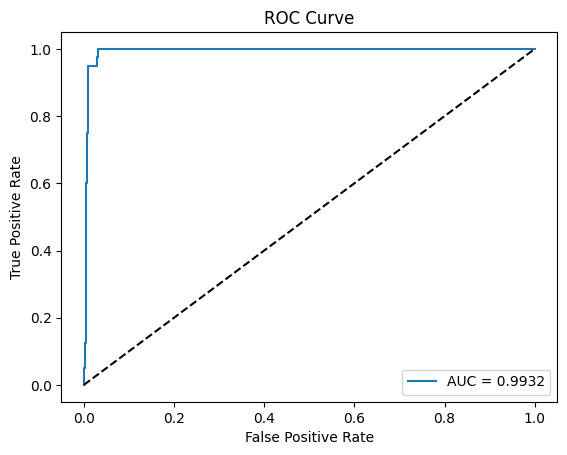

In [20]:
random_forest.fit(X_train, y_train)
y_probs = random_forest.predict_proba(X_test)[:, 1]
y_pred = random_forest.predict(X_test)
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs)
auc_score = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


/tmp/ipykernel_25871/1984091527.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_25871/1984091527.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


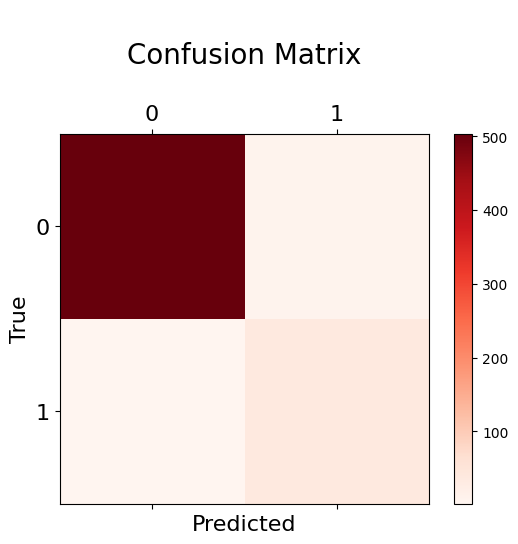

In [21]:

labels = [0,1]
y_pred = random_forest.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred, labels=labels)
def plot_cmatrix(cm,labels,title='Confusion Matrix'):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = ax.matshow(cm,cmap='Reds')
  plt.title('\n'+title+'\n', fontsize=20)
  fig.colorbar(cax)
  ax.set_xticklabels([''] + labels, fontsize=16)
  ax.set_yticklabels([''] + labels, fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.show()
plot_cmatrix(cm,labels)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9818511796733213


## Hyperparameter tuning

In [23]:
# Hyperparmater tuning

from sklearn.model_selection import GridSearchCV
# create dictornary to search and find the best parameters for rf
param_grid = {
    "n_estimators": [10,20,30],
    "max_depth" : [10,30,50,70,90,110],
    "min_samples_leaf": [5,10,15,],

    }


In [24]:
rf_cv = GridSearchCV(estimator=random_forest, param_grid=param_grid, scoring="neg_mean_squared_error", n_jobs = -1)
rf_cv.fit(X_train, y_train.values.ravel())

GridSearchCV(estimator=RandomForestClassifier(criterion='entropy', max_depth=5,
                                              min_samples_leaf=5,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 30, 50, 70, 90, 110],
                         'min_samples_leaf': [5, 10, 15],
                         'n_estimators': [10, 20, 30]},
             scoring='neg_mean_squared_error')

In [25]:
y_predh = rf_cv.predict(X_test)
y_val_predict = rf_cv.predict(X_val)

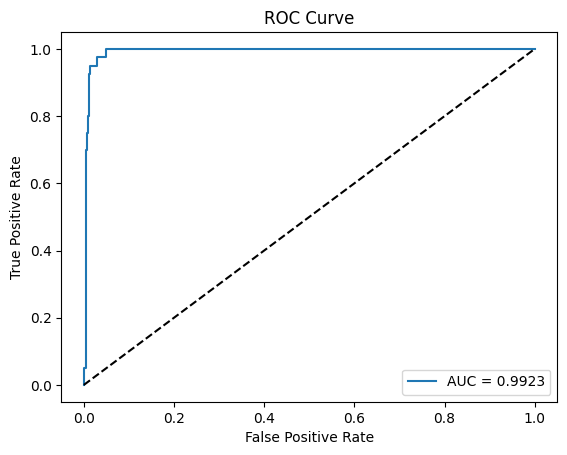

In [26]:
rf_cv.fit(X_train, y_train)
y_probs = rf_cv.predict_proba(X_test)[:, 1]
y_pred = rf_cv.predict(X_test)
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs)
auc_score = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


/tmp/ipykernel_25871/1395118898.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_25871/1395118898.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


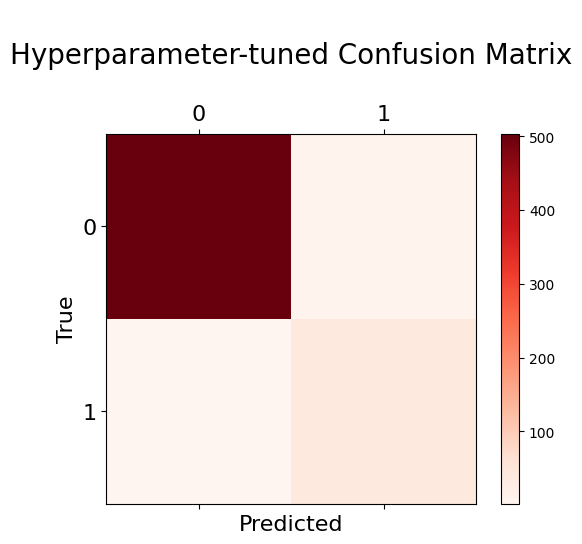

In [27]:
labels = [0,1]
y_pred = rf_cv.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_predh, labels=labels)
def plot_cmatrix(cm,labels,title='Hyperparameter-tuned Confusion Matrix'):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = ax.matshow(cm,cmap='Reds')
  plt.title('\n'+title+'\n', fontsize=20)
  fig.colorbar(cax)
  ax.set_xticklabels([''] + labels, fontsize=16)
  ax.set_yticklabels([''] + labels, fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.show()
plot_cmatrix(cm,labels)

In [28]:
importances = random_forest.feature_importances_
names = train_data.drop(columns=["class"]).columns

feature_df = pd. DataFrame({
    'Feature': names, 'Importance': importances

}).sort_values(by='Importance', ascending=False)

feature_df


,Feature,Importance
17,tsh,0.643862
25,fti,0.118889
21,tt4,0.106395
19,t3,0.032095
2,on thyroxine,0.024918
0,age,0.019098
16,tsh measured,0.014686
23,t4u,0.014428
9,query hypothyroid,0.007693
1,sex,0.004551


# Regression (Emma)

## Fill in missing with mean, and median

In [29]:
# First imputation cell
from sklearn.impute import SimpleImputer

missing_quantitative = ['age', 'tsh', 't3', 'tt4', 't4u', 'fti']

imputer_mean = SimpleImputer(
    missing_values=np.nan,
    strategy="mean"
)

imputer_mean.fit(X_train[missing_quantitative])

X_train[missing_quantitative] = imputer_mean.transform(
    X_train[missing_quantitative]
)

X_val[missing_quantitative] = imputer_mean.transform(
    X_val[missing_quantitative]
)

In [31]:
from sklearn.impute import SimpleImputer

imputer_mean = SimpleImputer(
    missing_values=np.nan,
    strategy="median"
)

imputer_mean = imputer_mean.fit(X_train)

X_train = imputer_mean.transform(X_train)
X_val = imputer_mean.transform(X_val)
X_test = imputer_mean.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [32]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
print(logreg.score(X_val, y_val))

0.9659863945578231


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Regression model evaluation, ROC, CM, importance

In [34]:
from sklearn import metrics

### Your code here
y_val_prob = logreg.predict_proba(X_val)
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob[:, 1])
roc_auc = metrics.auc(fpr, tpr)

print(roc_auc)

0.9901418194396403


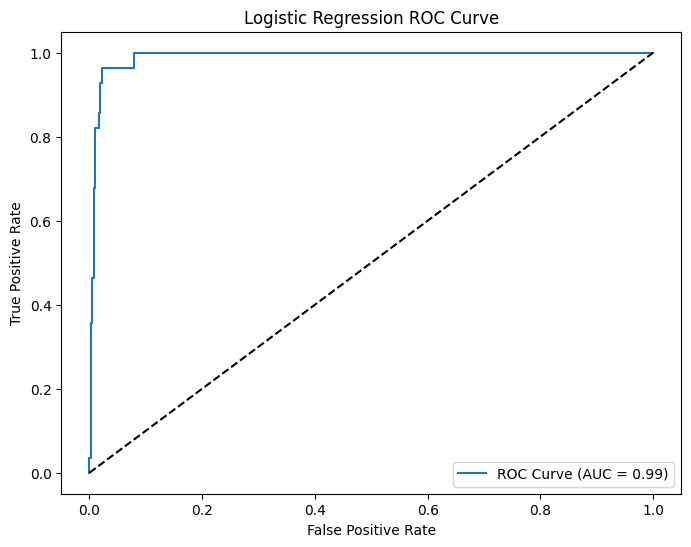

In [35]:
import matplotlib.pyplot as plt
### Your code here
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

<Axes: >

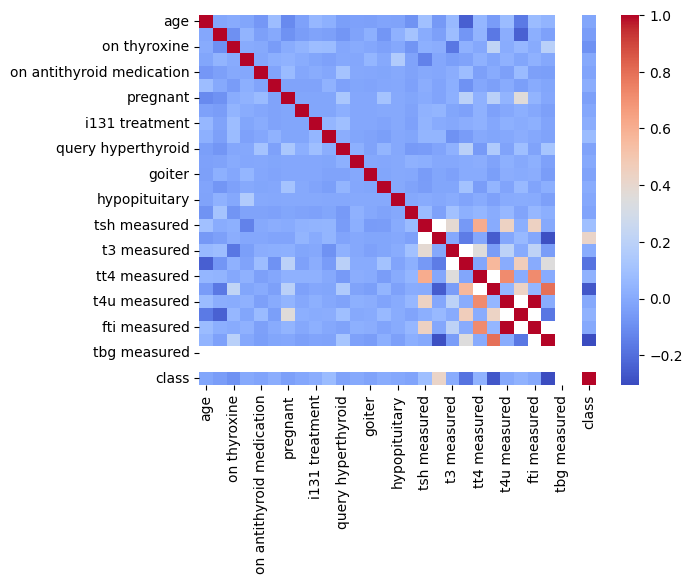

In [36]:
import seaborn as sns
correlation_matrix = train_data.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm")

In [37]:


feature_importance = pd.DataFrame({
    "Feature_Index": range(len(logreg.coef_[0])),
    "Importance": abs(logreg.coef_[0]),
    "Coefficient": logreg.coef_[0]
})

top5 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(5)

print(top5)

    Feature_Index  Importance  Coefficient
2               2    5.352864    -5.352864
16             16    1.837548     1.837548
7               7    1.626456    -1.626456
23             23    0.768054    -0.768054
4               4    0.485361    -0.485361


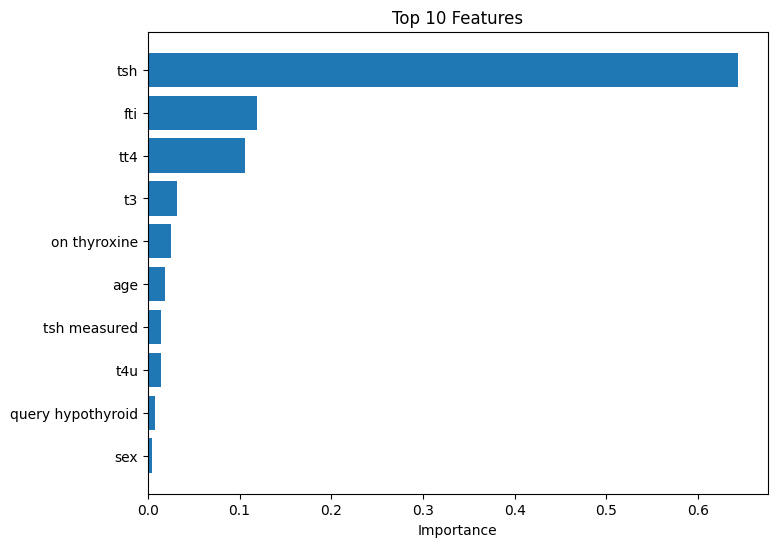

In [38]:
top_features = feature_df.head(10).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features')
plt.show()

Confusion Matrix:
[[505   6]
 [ 11  29]]


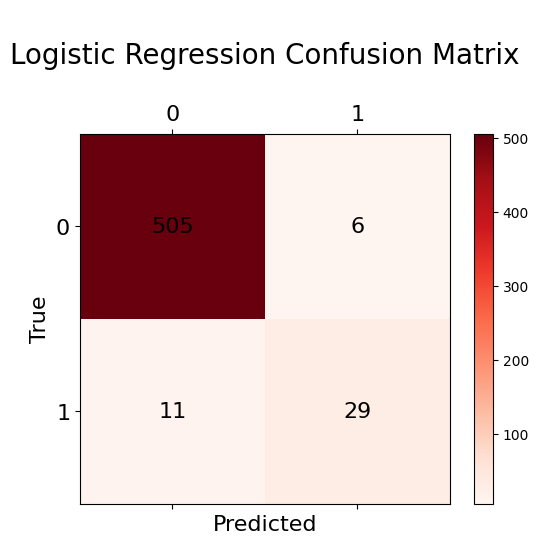

In [39]:
print('Confusion Matrix:')
labels = [0,1]
y_pred = logreg.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

def plot_cmatrix(cm, labels, title='Logistic Regression Confusion Matrix'):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(cm, cmap='Reds')
    plt.title('\n' + title + '\n', fontsize=20)
    fig.colorbar(cax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=16)
    ax.set_yticklabels(labels, fontsize=16)

    # Add the confusion matrix values
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=16, color='black')
    plt.xlabel('Predicted', fontsize=16)
    plt.ylabel('True', fontsize=16)
    plt.show()

plot_cmatrix(cm,labels)

In [40]:
print("Training Accuracy:", logreg.score(X_train, y_train) * 100, "%")
print("Test Accuracy:", logreg.score(X_test, y_test) * 100, "%")

Training Accuracy: 97.27427597955707 %
Test Accuracy: 96.91470054446461 %


# KNN (Vrajesh)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train_knn = X_train.copy()
X_val_knn = X_val.copy()
X_test_knn = X_test.copy()

scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train_knn)
X_val_knn = scaler.transform(X_val_knn)
X_test_knn = scaler.transform(X_test_knn)

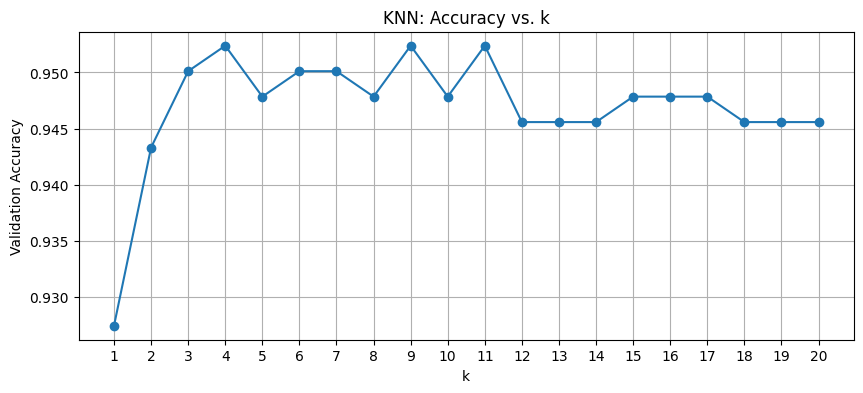

Best k: 4 | Validation Accuracy: 0.9524


In [44]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)

    y_val_pred = knn.predict(X_val_knn)
    accuracies.append(
        accuracy_score(y_val, y_val_pred)
    )

plt.figure(figsize=(10, 4))
plt.plot(k_range, accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("KNN: Accuracy vs. k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k = list(k_range)[np.argmax(accuracies)]

print(
    f"Best k: {best_k} | "
    f"Validation Accuracy: {max(accuracies):.4f}"
)

In [45]:
### training final model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_knn, y_train)

KNeighborsClassifier(n_neighbors=4)

## KNN model evaluation, ROC, CM, importance

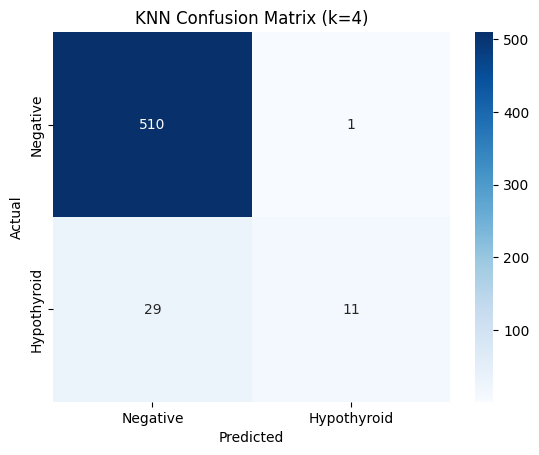

Sensitivity: 0.2750
Specificity: 0.9980
Test Accuracy:    0.9456
Train Accuracy:    0.9392
AUROC:       0.7505
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.97       511
 Hypothyroid       0.92      0.28      0.42        40

    accuracy                           0.95       551
   macro avg       0.93      0.64      0.70       551
weighted avg       0.94      0.95      0.93       551



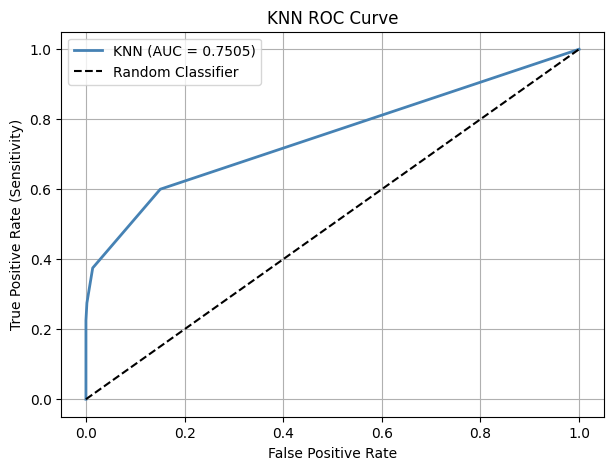

In [46]:
# ── Evaluate ─────────────────
y_pred      = knn_final.predict(X_test_knn)
y_pred_prob = knn_final.predict_proba(X_test_knn)
y_pred_train = knn_final.predict(X_train_knn)


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Hypothyroid'],
            yticklabels=['Negative', 'Hypothyroid'])
plt.title(f'KNN Confusion Matrix (k={best_k})')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()


tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"Train Accuracy:    {accuracy_score(y_train,y_pred_train):.4f}")
print(f"AUROC:       {roc_auc_score(y_test, y_pred_prob[:,1]):.4f}")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Hypothyroid']))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
auc_score   = roc_auc_score(y_test, y_pred_prob[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'KNN (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('KNN ROC Curve'); plt.legend(); plt.grid(True); plt.show()

#